# 5. Densité d'états de phonons 

#### Imports et récupération de la structure

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from pymatgen.ext.matproj import MPRester
from pymatgen.symmetry.analyzer import SpacegroupAnalyzer
from pymatgen.analysis.diffraction.xrd import XRDCalculator

from pymatgen.electronic_structure.plotter import BSPlotter
from pymatgen.phonon.plotter import PhononBSPlotter
from pymatgen.phonon.plotter import PhononDosPlotter

from scipy.optimize import curve_fit
from scipy.constants import hbar, k as k_B
from scipy import integrate

API_KEY = "vKJsFu0jdhLy7CJj5Mwar6S68kxgMc3n"
MP_ID = "mp-1008556"  

with MPRester(API_KEY) as mpr:
    structure = mpr.get_structure_by_material_id(MP_ID)
    phonon_bs = mpr.get_phonon_bandstructure_by_material_id(MP_ID)
    ph_dens = mpr.get_phonon_dos_by_material_id(MP_ID)

## 5.1 Densité d'états de phonons du matériau

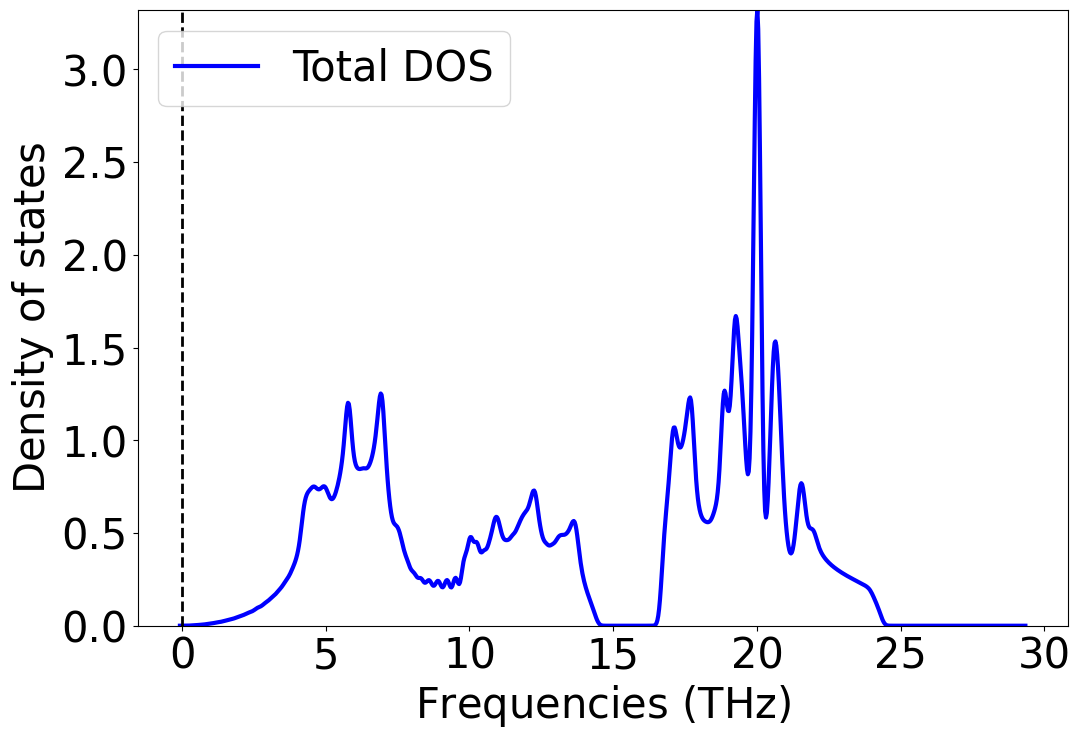

In [2]:
plotter = PhononDosPlotter()
plotter.add_dos("Total DOS", ph_dens)

fig_ph_dens = plotter.get_plot()
plt.show()

## 5.2 Calcul des températures de Debye $\Theta_D$ et d'Einstein $\Theta_E$

Nous cherchons ici à modéliser l'évolution de la chaleur spécifique à volume constant ($C_v$) en fonction de la température à l'aide de deux modèles classiques : le modèle d'Einstein et le modèle de Debye. 

Afin de pouvoir comparer ces modèles à notre matériau, nous normalisons la chaleur spécifique obtenue numériquement par $3N_{at}R$ (où $N_{at}$ est le nombre d'atomes dans la maille et $R$ la constante des gaz parfaits). Nous obtenons ainsi une courbe qui, à haute température, tend asymptotiquement vers $1$, respectant la loi de Dulong-Petit.

**Modèle d'Einstein :**
Ce modèle est une approximation de la capacité thermique des solides basée sur l’hypothèse que tous les atomes d’un cristal oscillent indépendamment avec la même fréquence, appelée fréquence d’Einstein, $\omega_E$. Il suppose que ces oscillations suivent la statistique de Bose-Einstein. La capacité thermique est calculée en intégrant l’énergie moyenne d’un oscillateur quantique sur toutes les températures. Pour représenter et analyser cette formule, il est pratique de définir la température d'Einstein par : $k_{B}\Theta_E = \hbar\omega_E$. Cela donne l’expression normalisée suivante:

$$\frac{C_v^{Einstein}}{3N_{at}R} = \left(\frac{\Theta_E}{T}\right)^2 \frac{e^{\Theta_E/T}}{(e^{\Theta_E/T}-1)^2}$$

**Modèle de Debye :**
Ce modèle est une amélioration du modèle d'Einstein qui prend en compte l’interaction collective des vibrations des atomes dans un solide. Il suppose que les modes de vibration suivent une distribution continue jusqu'à une fréquence maximale, appelée fréquence de Debye, $\omega_D$. La capacité thermique $C_v$ est obtenue par intégration de la densité d’états des phonons. Pour représenter et analyser cette formule, il est pratique de définir la température de Debye par : $k_{B}\Theta_D = \hbar\omega_D$. Cela donne l’expression normalisée suivante:

$$\frac{C_v^{Debye}}{3N_{at}R} = 3 \left(\frac{T}{\Theta_D}\right)^3 \int_0^{\Theta_D/T} \frac{x^4 e^x}{(e^x-1)^2} dx$$

Pour déterminer les températures $\Theta_E$ et $\Theta_D$ propres à notre composé, nous allons tester numériquement les températures comprises entre 1 K et 1000 K et conserver celles qui minimisent l'erreur au sens des moindres carrés par rapport aux données de Materials Project.

In [3]:
# --- Préparation des données expérimentales ---
# On commence à 5K pour éviter l'erreur de division par zéro dans les modèles
temperatures = np.arange(5, 1005, 5) 
R = 8.314 
Nat = len(structure) 

# Récupération et normalisation de la chaleur spécifique
exp_cv = np.array([ph_dens.cv(T) for T in temperatures]) / (3 * Nat * R)

# --- Recherche de la température d'Einstein ---
def cv_einstein(theta_E, T):
    x = theta_E / T
    return (x**2 * np.exp(x)) / ((np.exp(x) - 1)**2)

err_e_min = float('inf') 
temp_e = 0

for theta in range(1, 1000): 
    erreur_totale = 0
    for i in range(len(temperatures)): 
        cv_pred = cv_einstein(theta, temperatures[i])
        erreur_totale += (cv_pred - exp_cv[i])**2
        
    if erreur_totale < err_e_min: 
        temp_e = theta
        err_e_min = erreur_totale

print(f"Température d'Einstein minimisant l'erreur : {temp_e} K")

# --- Recherche de la température de Debye ---
def integrand_debye(x):
    return (x**4 * np.exp(x)) / ((np.exp(x) - 1)**2)

def cv_debye(theta_D, T):
    integral, _ = integrate.quad(integrand_debye, 0, theta_D / T)
    return 3 * (T / theta_D)**3 * integral

err_d_min = float('inf')
temp_d = 0

for theta in range(1, 1000):
    erreur_totale = 0
    for i in range(len(temperatures)):
        cv_pred = cv_debye(theta, temperatures[i])
        erreur_totale += (cv_pred - exp_cv[i])**2
        
    if erreur_totale < err_d_min:
        temp_d = theta
        err_d_min = erreur_totale

print(f"Température de Debye minimisant l'erreur : {temp_d} K")

Température d'Einstein minimisant l'erreur : 640 K
Température de Debye minimisant l'erreur : 866 K


## 5.3 Représentation des trois courbes de chaleur spécifique 

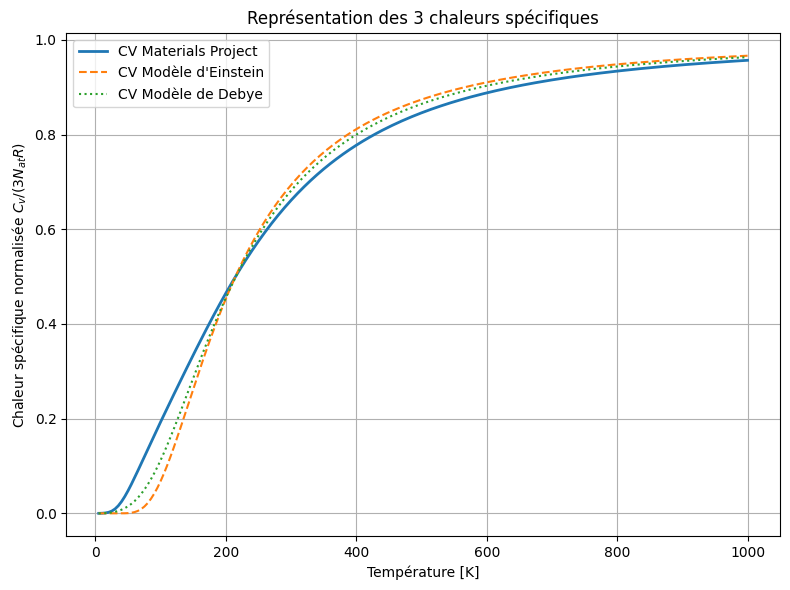

In [4]:
# Calcul des capacités thermiques prédites des deux modèles
cv_e_pred = np.array([cv_einstein(temp_e, T) for T in temperatures])
cv_d_pred = np.array([cv_debye(temp_d, T) for T in temperatures])

# Plot
plt.figure(figsize=(8,6))

plt.plot(temperatures, exp_cv, label="CV Materials Project", linewidth=2)
plt.plot(temperatures, cv_e_pred, label=f"CV Modèle d'Einstein", linestyle="--")
plt.plot(temperatures, cv_d_pred, label=f"CV Modèle de Debye", linestyle=":")

plt.xlabel("Température [K]")
plt.ylabel(r"Chaleur spécifique normalisée $C_v / (3N_{at}R)$")
plt.title("Représentation des 3 chaleurs spécifiques")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

#### Analyse des courbes de chaleur spécifique

À haute température, les trois courbes convergent vers 1, c’est-à-dire vers la limite $C_{v} = 3N_{at}R$, conformément à la loi de Dulong-Petit. Les deux modèles décrivent donc correctement le comportement asymptotique du cristal dans ce régime.

En revanche, les différences apparaissent surtout à basse température. Le modèle de Debye prédit que, lorsque $T \ll \Theta_D$, la chaleur spécifique varie comme $C_{v} \propto T^3$. Ce comportement provient du fait qu’à très basse température, seuls les modes acoustiques de faible fréquence contribuent significativement, tandis que les modes optiques peuvent être négligés. Cela explique pourquoi la courbe de Debye reproduit mieux la croissance progressive observée sur les données numériques dans la zone des basses températures. 

Le modèle d’Einstein, au contraire, suppose que tous les atomes vibrent à une fréquence unique. Pour $T \ll \Theta_E$, la chaleur spécifique suit une loi exponentielle $C_{v} \propto e^{-\Theta_E/T}$. La courbe d’Einstein reste donc trop faible aux très basses températures, puis augmente plus brusquement, ce qui rend ce modèle moins fidèle au comportement réel du matériau. Cela s'explique par le fait que le modèle d’Einstein ne prend pas en compte la dispersion des phonons.

Dans la région intermédiaire, les deux modèles se rapprochent des données du Materials Project, mais le modèle de Debye reste globalement le plus cohérent physiquement, car il tient compte d’un spectre continu de vibrations et de la contribution correcte des phonons acoustiques. Ainsi, l’analyse du graphe confirme les prédictions théoriques du cours : le modèle de Debye fournit une description plus réaliste de la chaleur spécifique, en particulier à basse température.

## 5.4 Représenter les trois densités d'états de phonons correspondantes.

Pour représenter les densités de modes, on utilise les fréquences des différents modèles.   
Nous avons donc commencé ici par calculer les fréquences de Debye et Einstein.On a pu les trouver en remplaçant les omega par des fréquences:  
$ \omega_D = 2\pi\nu_D $ et $\omega_E = 2\pi\nu_E$    
  
Sachant que $\hbar= h * 2\pi$,
nous avons donc pu ensuite utiliser ces formules:    
- $ k* \Theta_D = h* \nu_D $ 
- $ k* \Theta_E = h* \nu_E $

La densité des modes normaux, qui est aussi la densité d'états des phonons est normalisée pour avoir : $\int g(\omega)\, d\omega = 3 N_{\mathrm{at}}$.  

Pour le modèle d'Einstein, $ g(\omega)\ $ est un delta de Dirac piqué en $ \omega_E $ : $ g_E(\omega)\ = 3 N_{at} * \delta(\omega - \omega_E) $    

Pour le modèle de Debye, $ g(\omega) $ est une fonction parabolique de la fréquence:    
On ne va utiliser que la fréquence:   
$$
g_D(\nu) =
\begin{cases}
A \nu^2 & \text{si } \nu < \nu_D \\
0 & \text{sinon}
\end{cases}
$$
On trouve la constante A par :  
$$
\int_0^{\nu_D} g_D(\nu)\, d\nu = 3N
$$
On calcule ce que vaut A:  
$$
\int_0^{\nu_D} A \nu^2 \, d\nu = A \frac{\nu_D^3}{3} = 3N
$$

$$
A = \frac{9N}{\nu_D^3}
$$  
On trouve donc la densité de Debye par : $ g_D= \frac{9N}{\nu_D^3} * \nu^2$ pour une fréquence plus petite que la fréquence de Debye.     
 

Nous obtenons donc finalement la densité d'états de phonons réelles, par le modèle d'Einstein et par le modèle de Debye.    
Nous voyons que nous avons un delta de Dirac pour le modèle d'Einstein à la fréquence $\nu_E $ = 13.34 .La densité est ici représentée par une ligne verticale.   
Pour le modèle de Debye, il est assez précis pour les petites fréquence (par rapport à la densité du matérials project), cela correspond aux phonons acoustiques, puis augmente et s'arrête lorqu'on dépasse la fréquence de Debye. Nous voyons bien qu'il a un comportement en $\nu^2$ à basse fréquence.   
La constante de Normalisation A est déterminée de manière à garantir que l'aire sous la courbe $ g_D(\nu)$ corresponde au nombre total de modes (3N). 

Fréquence de Debye (THz) : 18.04451216080168
Fréquence d'Einstein (THz) : 13.335436238929649


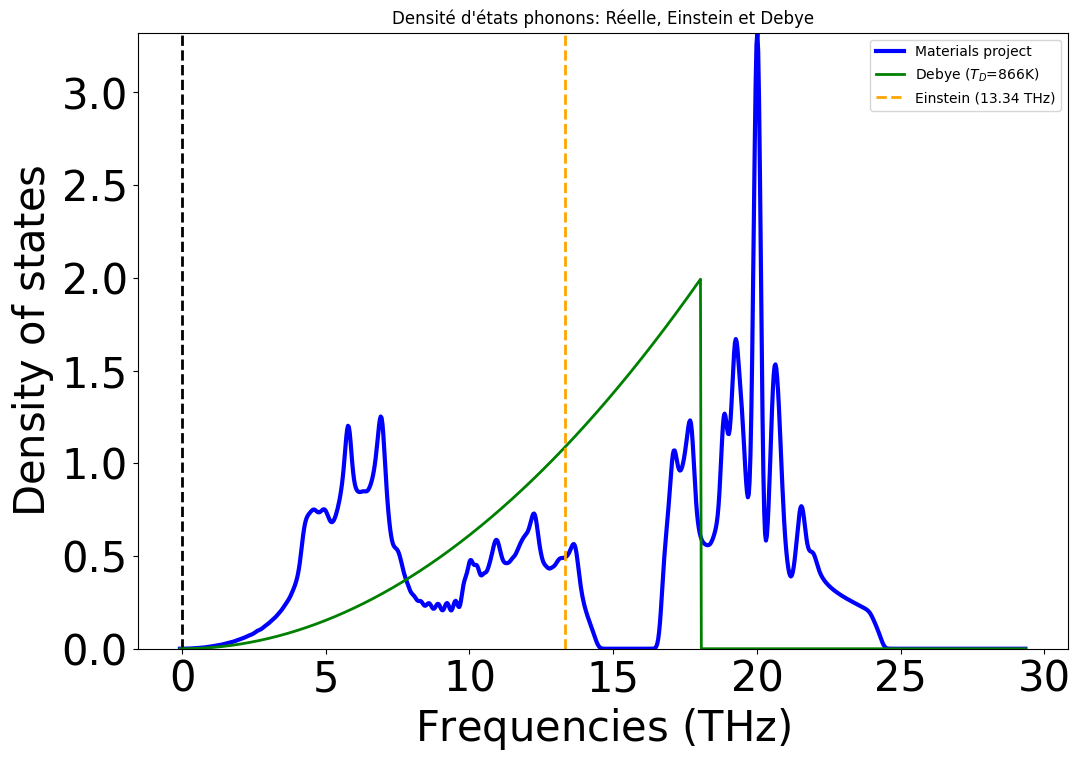

In [36]:
import scipy.constants as const
# on récupère la figure du 5.1
plotter = PhononDosPlotter()
plotter.add_dos("Materials project", ph_dens)
ax = plotter.get_plot()  


nu_max = ax.get_xlim()[1]
nu_th = ph_dens.frequencies

# calcul des modèles
nu_D = (const.k * temp_d) / const.h / 1e12
nu_E = (const.k * temp_e) / const.h / 1e12

# Modèle de Debye
densité_debye = np.zeros_like(nu_th)
mask = nu_th <= nu_D
densité_debye[mask] = (9 * Nat / nu_D**3) * nu_th[mask]**2
print("Fréquence de Debye (THz) :", nu_D)

# Modèle d'Einstein 
print("Fréquence d'Einstein (THz) :", nu_E)

# on met les courbes sur un même graphe 
ax.plot(nu_th, densité_debye, label=f"Debye ($T_D$={temp_d}K)", color='green', lw=2)
ax.axvline(nu_E, color='orange', linestyle='--', linewidth=2, label=f"Einstein ({nu_E:.2f} THz)")


ax.legend()
plt.title(f"Densité d'états phonons: Réelle, Einstein et Debye")
plt.show()